# HyFlood

! Important: add hydromt in the devcontainer

In [1]:
import os
import os.path as op
import shutil
import subprocess

import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt

In [2]:
root_dir = os.getcwd()

output_dir = op.join(root_dir, "output")
templates_dir = op.join(root_dir, "templates")
export_dir = op.join(root_dir, "export")

os.makedirs(export_dir, exist_ok=True)

## HyFlood input variables

In [3]:
# Input ranges
variables_bounds = {
    # Ocean forcing
    "Hs_min":  (0.5, 8.0),      # m
    "Hs_max":  (0.5, 8.0),      # m
    "Tp_min":  (5.0, 20.0),     # s
    "Tp_max":  (5.0, 20.0),     # s
    "Dir": (180.0, 330.0),  # deg
    
    "SL":  (-0.5, 2.5),     # m

    # Precipitation forcing
    "precipitation": (0.0, 250.0),
    "precip_duration": (0, 25),
    "AMC": (0, 1),
    "precip_wave_lag": (-5, 5)
}


In [4]:
variables_bounds.keys()

dict_keys(['Hs_min', 'Hs_max', 'Tp_min', 'Tp_max', 'Dir', 'SL', 'precipitation', 'precip_duration', 'AMC', 'precip_wave_lag'])

## LHS Synthetic Generation

In [5]:
from bluemath_tk.datamining.lhs import LHS

# Generate LHS
lhs = LHS(num_dimensions=len(list(variables_bounds.keys())))

df_dataset = lhs.generate(
    dimensions_names=list(variables_bounds.keys()),
    lower_bounds=[bounds[0] for bounds in variables_bounds.values()],
    upper_bounds=[bounds[1] for bounds in variables_bounds.values()],
    num_samples=10_000,
)

df_dataset

,Hs_min,Hs_max,Tp_min,Tp_max,Dir,SL,precipitation,precip_duration,AMC,precip_wave_lag
0,1.712366,2.990787,9.298784,7.655077,315.400323,-0.050127,236.004307,20.746477,0.052745,-0.407028
1,6.730435,2.331846,14.569505,9.938317,309.955452,0.364164,30.696649,4.303992,0.916780,-4.548262
2,2.629437,7.963790,5.587272,18.330529,310.170575,0.672183,78.911469,0.399308,0.622684,4.947030
3,5.256863,6.481913,10.330065,7.431835,239.465805,2.201525,142.974010,21.266179,0.220254,-3.397062
4,7.803769,1.529861,17.756611,16.171610,317.312402,-0.075953,112.362228,1.198117,0.401185,-4.027820
...,...,...,...,...,...,...,...,...,...,...
9995,7.925388,6.124083,16.629806,8.783875,222.046067,1.115527,218.665685,8.688318,0.464288,1.239829
9996,7.263586,1.396192,8.181982,19.697368,272.277887,1.030389,95.947671,6.180696,0.466765,-3.190517
9997,5.616182,1.201755,16.742767,18.884838,297.350463,0.797815,7.149716,15.871460,0.299995,3.946501
9998,2.079458,5.724227,19.684948,8.578857,199.870898,1.631649,148.472267,21.785236,0.447567,-1.925107


## MDA Selection

In [7]:
from bluemath_tk.datamining.mda import MDA

mda_samples = 2

mda = MDA(num_centers=mda_samples)
mda.fit(data=df_dataset, normalize_data=True)

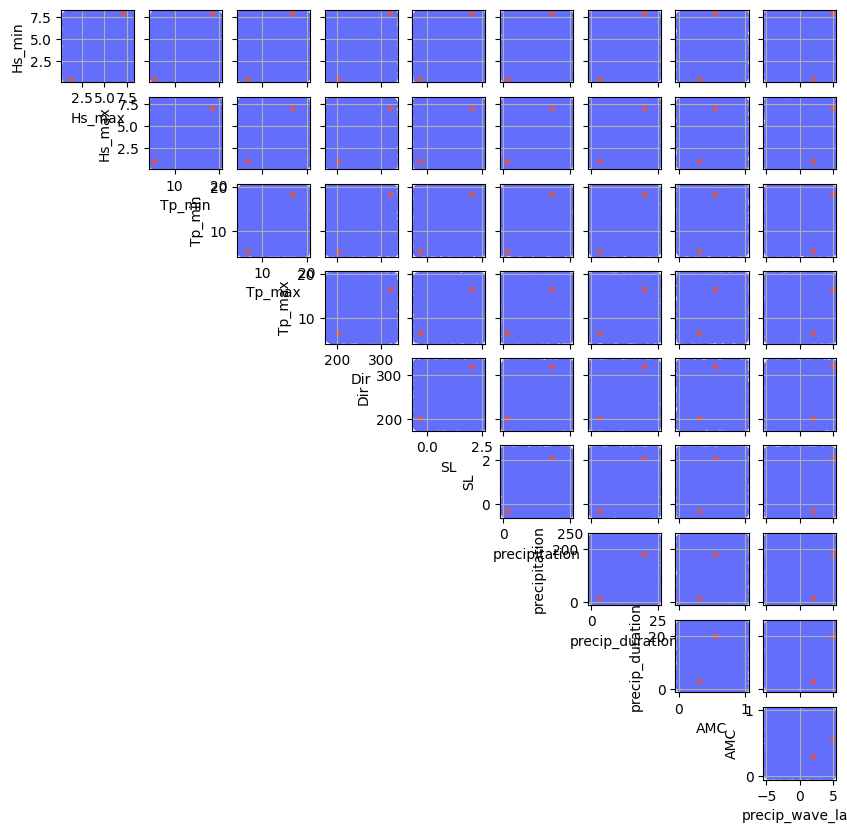

In [8]:
fig, axes = mda.plot_selected_centroids(
    s=12,
    data_color=px.colors.qualitative.Plotly[0],
    centroids_color=px.colors.qualitative.Plotly[1],
)

fig.set_size_inches(10, 10)
plt.show()

## Plot Input Scenarios

## 2. Numerical model: SFINCS

In [9]:
from utils.forcing import build_waterlevel_forcings, build_precipitation_forcings

In [10]:
# Calculate Msetup and Hig from HySwash
Msetup = [0.1 for i in mda.centroids]
Hig = [0.5 for i in mda.centroids]

In [11]:
sfincs_ref = "2000-01-01 00:00:00"

In [12]:
slowly_waterlevel_forcing, quickly_waterlevel_forcing = (
    build_waterlevel_forcings(
        msetup=Msetup,
        h_ig=Hig,
        msl=mda.centroids["SL"].values,
        time=np.arange(24),
        reference_time=sfincs_ref,
    )
)

In [13]:
precipitation_forcing = build_precipitation_forcings(
    mda.centroids,
    reference_time=sfincs_ref,
)


In [14]:
metamodel_parameters = {
    "slowly_waterlevel_forcing": slowly_waterlevel_forcing,
    "quickly_waterlevel_forcing": quickly_waterlevel_forcing,
    "precipitation_forcing": precipitation_forcing,
}

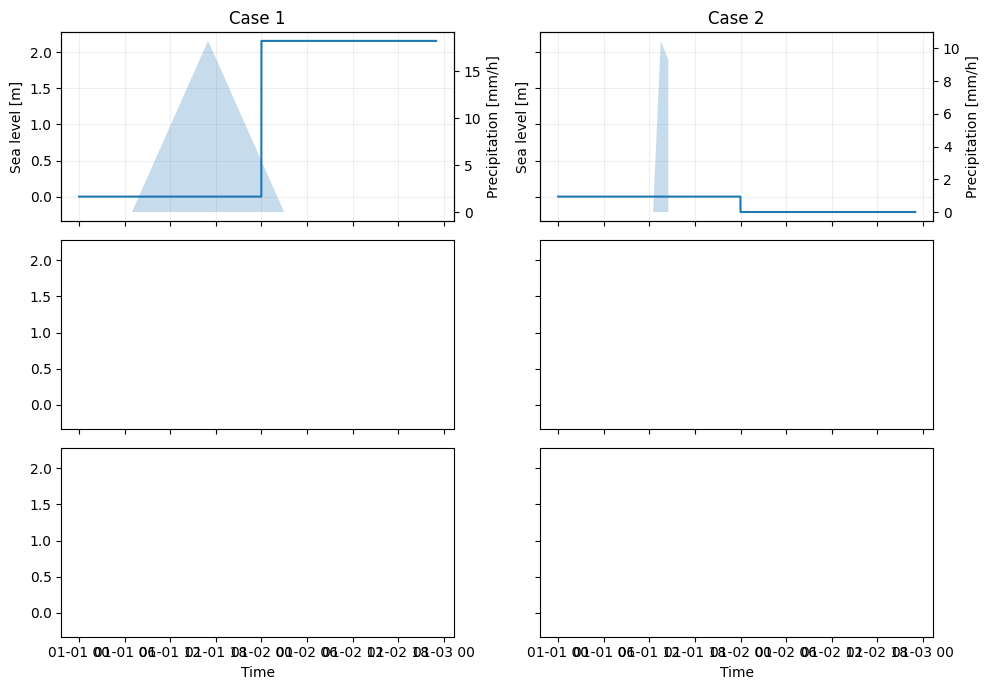

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    3, 2,
    figsize=(10, 7),
    sharex=True,
    sharey=True,
)

axes = axes.ravel()

for i, case in mda.centroids[:6].iterrows():

    ax = axes[i]

    slowly_varying = slowly_waterlevel_forcing[i]
    quickly_varying = quickly_waterlevel_forcing[i]
    precip = precipitation_forcing[i]
    time = precipitation_forcing[i].index
    
    # Sea level
    ax.plot(slowly_varying)

    ax.set_ylabel("Sea level [m]")
    ax.set_title(f"Case {i+1}")

    # Precipitation
    ax2 = ax.twinx()

    ax2.fill_between(
        precip.index,
        0,
        precip.values.squeeze(),
        alpha=0.25,
        label="Precipitation",
    )

    ax2.set_ylabel("Precipitation [mm/h]")
    ax.grid(alpha=0.2)

for ax in axes[-2:]:
    ax.set_xlabel("Time")

plt.tight_layout()
plt.show()

In [16]:
import geopandas as gpd

coords = [412500.0, 4939800.0]

gdf_boundary_points = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy([coords[0]], [coords[1]]),
    crs=32610
)

gdf_boundary_points

,geometry
0,POINT (412500 4939800)


In [17]:
from utils.sfincs_wrapper import SfincsModelWrapper

fixed_parameters = {
    "x0": 413000.0,
    "y0": 4933400.0,
    "dx": 200.0,
    "dy": 200.0,
    "rotation": 0,
    "nmax": 62,
    "mmax": 79,
    "epsg": 32610,
    #"tref": "20151205 000000",
    #"tstart": "20151205 000000",
    #"tstop": "20151205 000000",
    "gdf_boundary_points":gdf_boundary_points
    #"path_to_inf_tif": 
}

sfincs_wrapper = SfincsModelWrapper(
    templates_dir="templates",
    templates_name=["sfincs.inp", "sfincs.ind", "sfincs.dep",  "sfincs.ind", "sfincs.msk", "sfincs_subgrid.nc"],
    metamodel_parameters=metamodel_parameters,
    fixed_parameters=fixed_parameters,
    output_dir=output_dir,
)


2026-09-25 22:14:57,166 - SfincsModelWrapper - WARNING - Parameter slowly_waterlevel_forcing is not in the default_parameters
2026-09-25 22:14:57,167 - SfincsModelWrapper - WARNING - Parameter quickly_waterlevel_forcing is not in the default_parameters
2026-09-25 22:14:57,169 - SfincsModelWrapper - WARNING - Parameter precipitation_forcing is not in the default_parameters


In [23]:
sfincs_wrapper.build_cases()


Model dir already exists and files might be overwritten: /workspaces/BlueMath_Course_Corvallis/methods/hybrid_downscaling/metamodel/hyflood/output/0000/gis.


In [ ]:
sfincs_wrapper.run_cases_in_background(launcher="serial", num_workers=2)


## Plot output results

In [14]:
from hydromt_sfincs import SfincsModel, utils
root = "/workspaces/BlueMath_Course_Corvallis/methods/hybrid_downscaling/metamodel/hyflood/output/0000"

sf = SfincsModel(root, mode="r")
sf.read_results()

print(sf.results.keys())

INFO:hydromt_sfincs.sfincs:Initializing sfincs model from hydromt_sfincs (v1.2.2).


dict_keys(['inp', 'msk', 'zb', 'zs', 'zsmax', 'zvolmax', 'total_runtime', 'average_dt', 'status'])


In [18]:
import xarray as xr
dep_hr = xr.open_dataset("/workspaces/BlueMath_Course_Corvallis/methods/hybrid_downscaling/metamodel/hyflood/templates/Newport_UTM.tif")
zsmax = sf.results["zsmax"].max(dim="timemax")
zsmax_hr = utils.downscale_floodmap(
    zsmax=zsmax,
    dep=dep_hr['band_data'],
)

zsmax_hr.name = "zsmax"

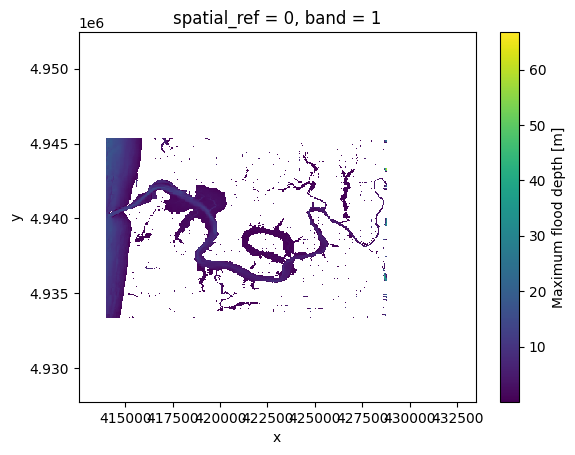

In [19]:
zsmax_hr.plot()